In [2]:
import os
from pathlib import Path
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

# ==============================
# 1. File path setting
# ==============================

DATA_DIR_CANDIDATES = [
    Path("PaPago_m4a"),
    Path("HailMary") / "PaPago_m4a",
]

DATA_DIR = next((path for path in DATA_DIR_CANDIDATES if path.is_dir()), None)
if DATA_DIR is None:
    raise FileNotFoundError("PaPago_m4a 폴더를 찾을 수 없습니다. Speech_Processing 또는 HailMary 폴더에서 노트북을 실행하세요.")

audio_files = {
    "BrownDog_English": "BrownDog_Papago_English.m4a",
    "BrownDog_Korea": "BrownDog_Papago_Korea.m4a",
    "BrownDog_Japan": "BrownDog_Papago_Japan.m4a",

    "Interesting_English": "Interesting_Papago_English.m4a",
    "Interesting_Korea": "Interesting_Papage_Korea.m4a",
    "Interesting_Japan": "Interesting_Papago_Japan.m4a",

    "Pizza_English": "Pizza_Papago_English.m4a",
    "Pizza_Korea": "Pizza_Papago_Korea.m4a",
    "Pizza_Japan": "Pizza_Papago_Japan.m4a",
}

sr_target = 22050

signals = {}

for label, filename in audio_files.items():
    path = DATA_DIR / filename

    y, sr = librosa.load(path, sr=sr_target)

    # Papago에서 다운로드한 음성은 앞뒤 무음이 크지 않을 가능성이 높아서 일단 사용하지 않음.
    # 나중에 직접 녹음한 음성을 사용할 때 필요하면 아래 줄의 주석을 해제하면 됨.
    # y, _ = librosa.effects.trim(y, top_db=30)

    signals[label] = {
        "y": y,
        "sr": sr,
        "duration": len(y) / sr
    }

    print(f"{label}: {signals[label]['duration']:.2f} sec")

BrownDog_English: 2.74 sec
BrownDog_Korea: 4.05 sec
BrownDog_Japan: 4.36 sec
Interesting_English: 3.16 sec
Interesting_Korea: 5.45 sec
Interesting_Japan: 4.91 sec
Pizza_English: 3.74 sec
Pizza_Korea: 5.62 sec
Pizza_Japan: 6.03 sec


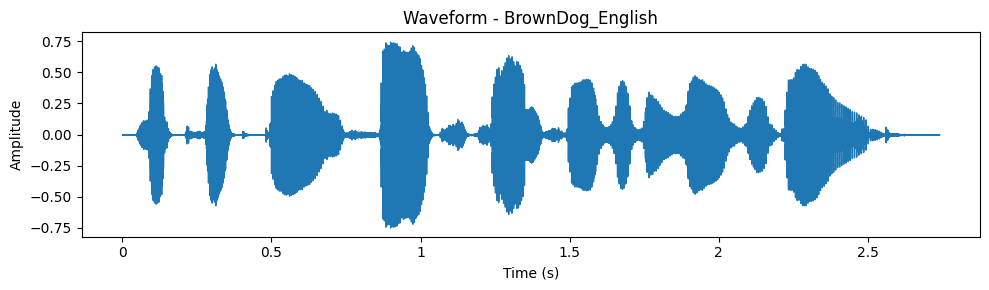

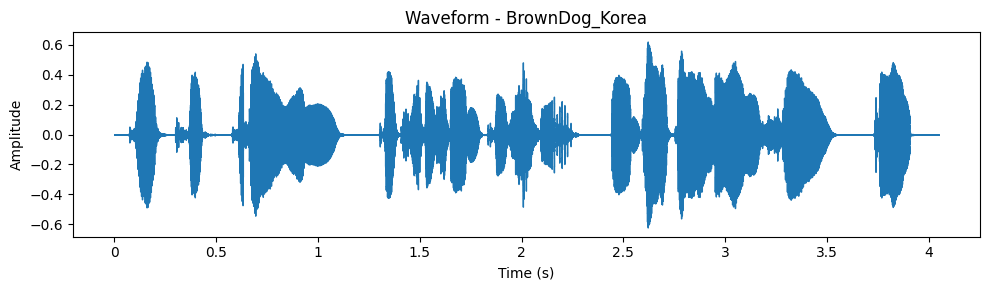

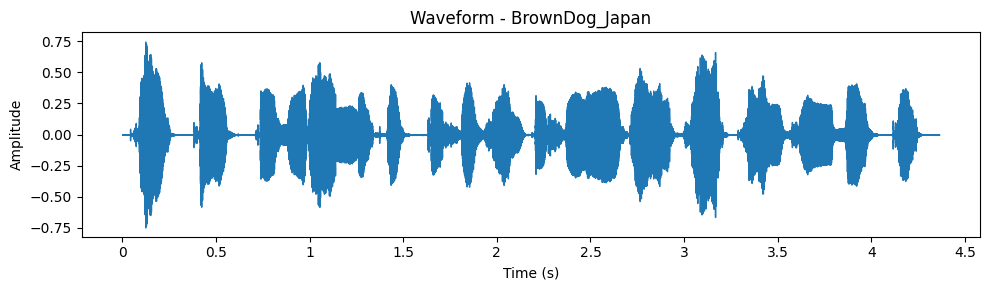

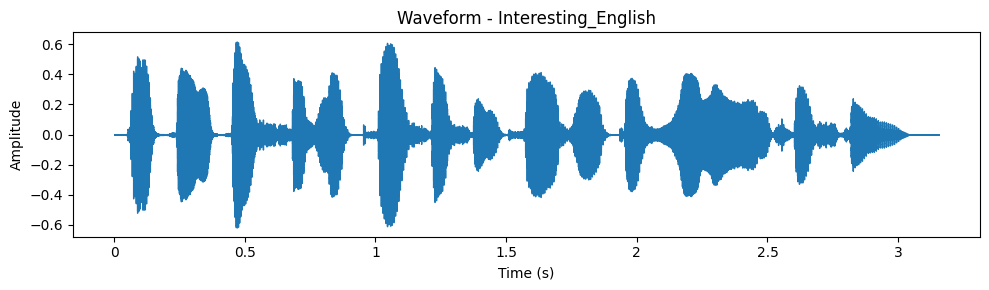

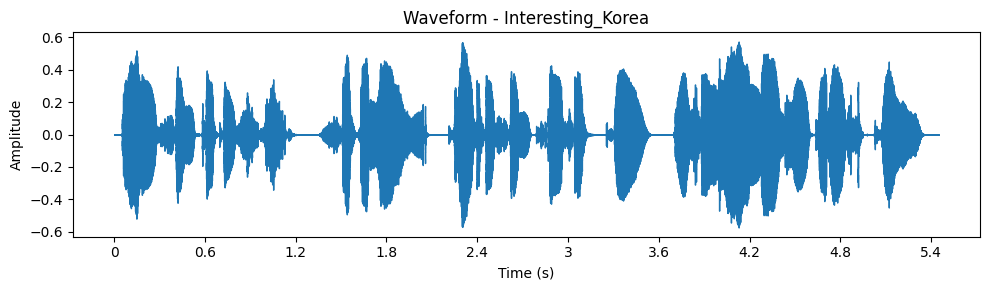

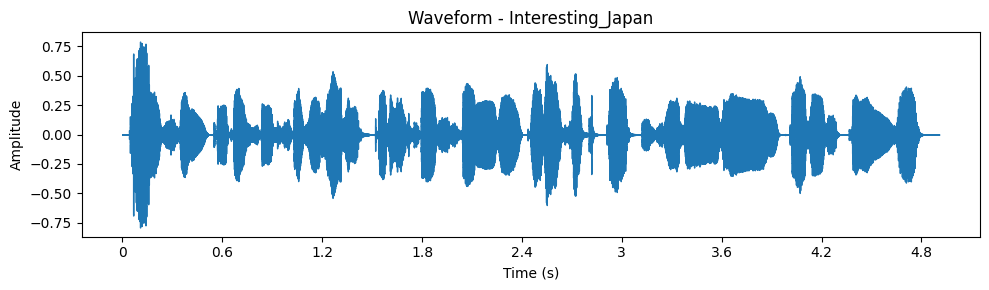

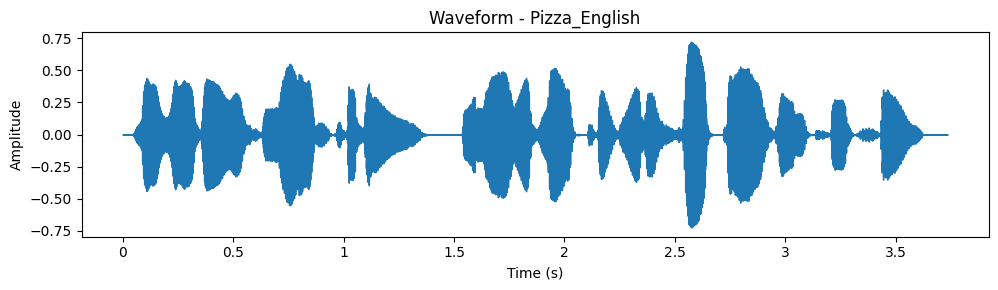

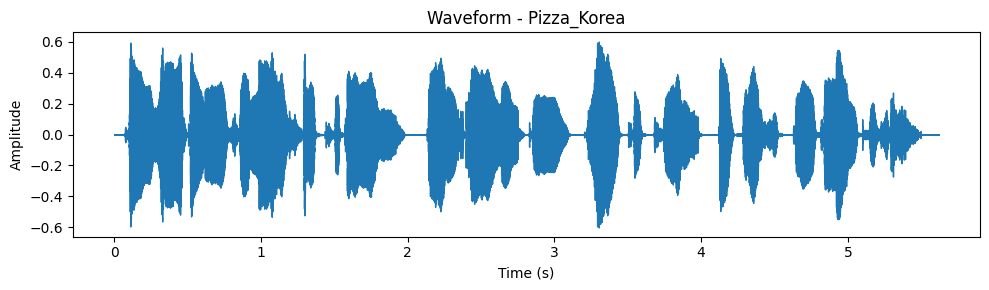

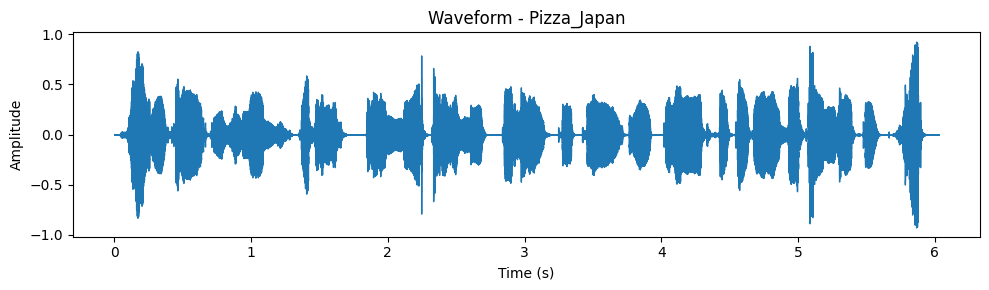

In [3]:
# Waceform 각각 보기
for label, data in signals.items():
    y = data["y"]
    sr = data["sr"]

    plt.figure(figsize=(10, 3))
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Waveform - {label}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()
    plt.close()

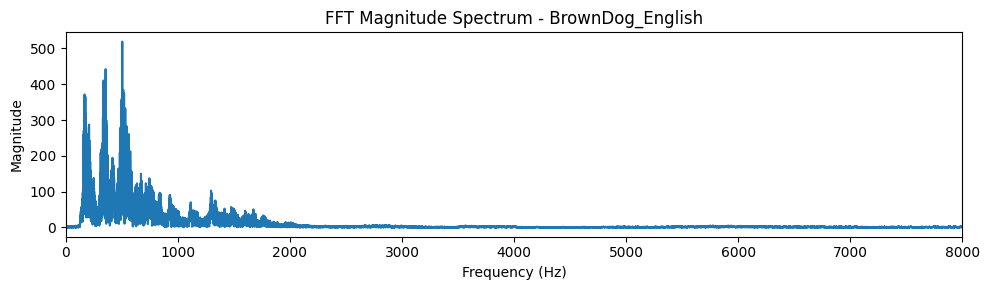

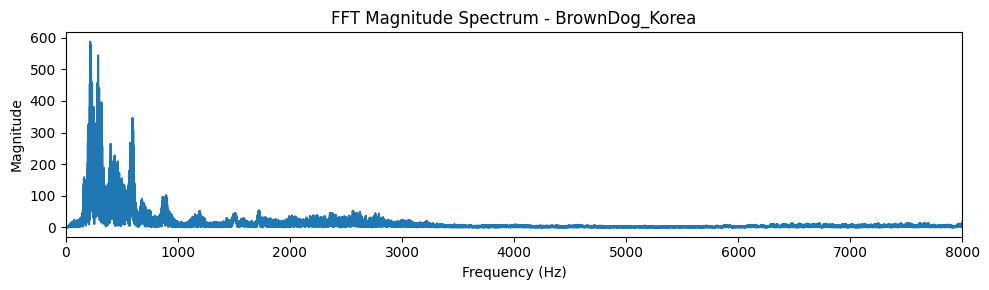

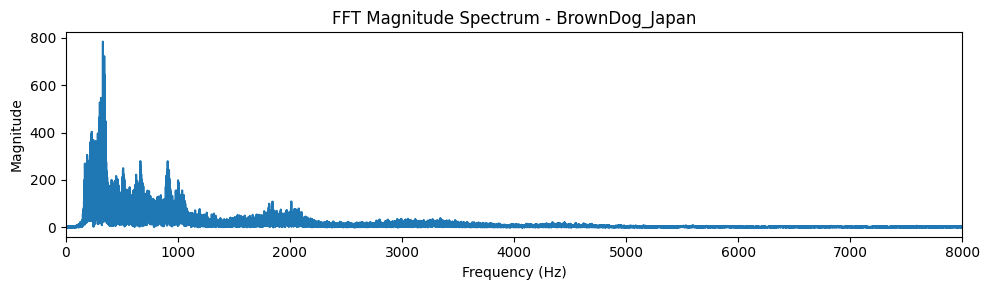

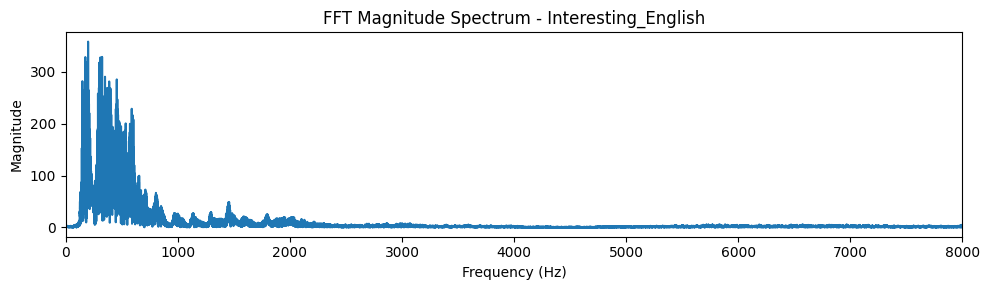

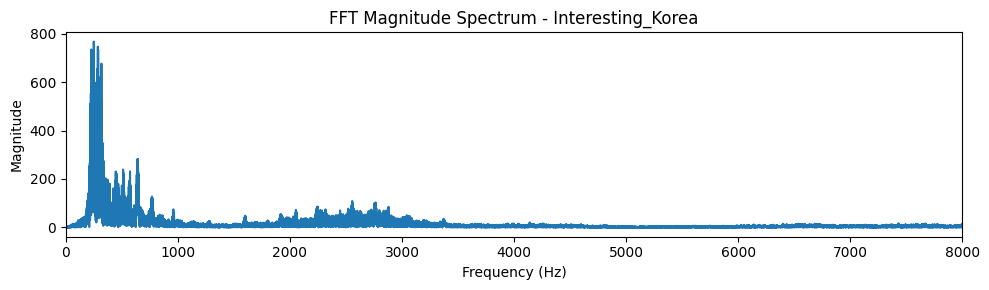

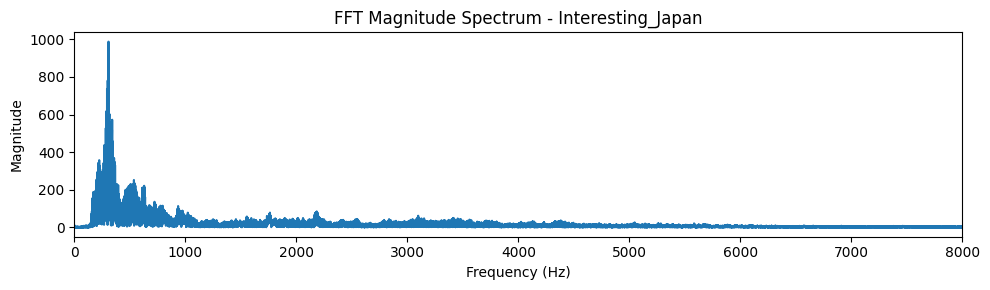

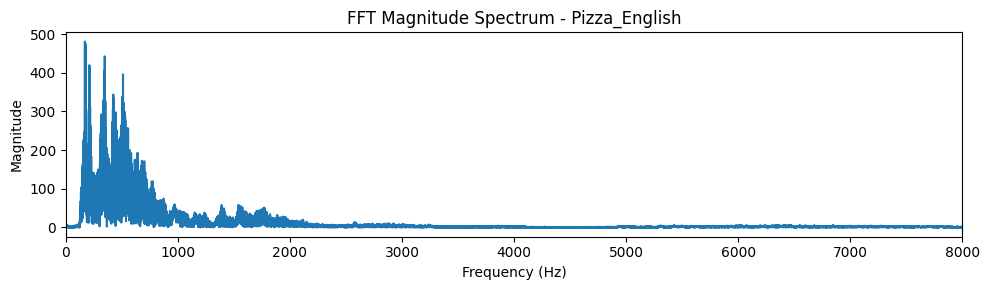

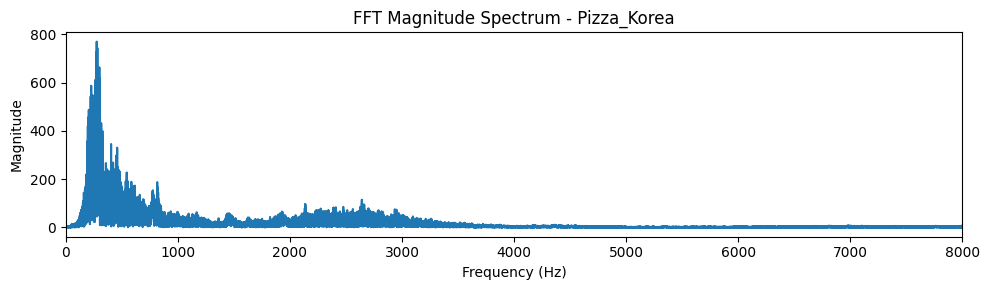

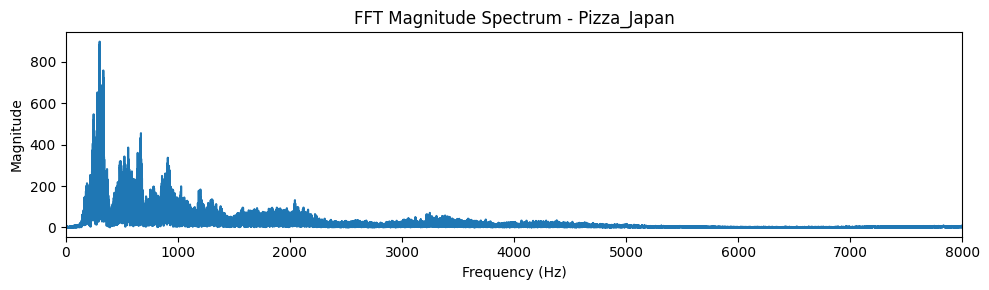

In [4]:
# FFT Spectrum 각각 보기
for label, data in signals.items():
    y = data["y"]
    sr = data["sr"]

    N = len(y)
    Y = np.fft.fft(y)
    freqs = np.fft.fftfreq(N, d=1/sr)

    half = N // 2

    plt.figure(figsize=(10, 3))
    plt.plot(freqs[:half], np.abs(Y[:half]))
    plt.title(f"FFT Magnitude Spectrum - {label}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.xlim(0, 8000)
    plt.tight_layout()
    plt.show()
    plt.close()

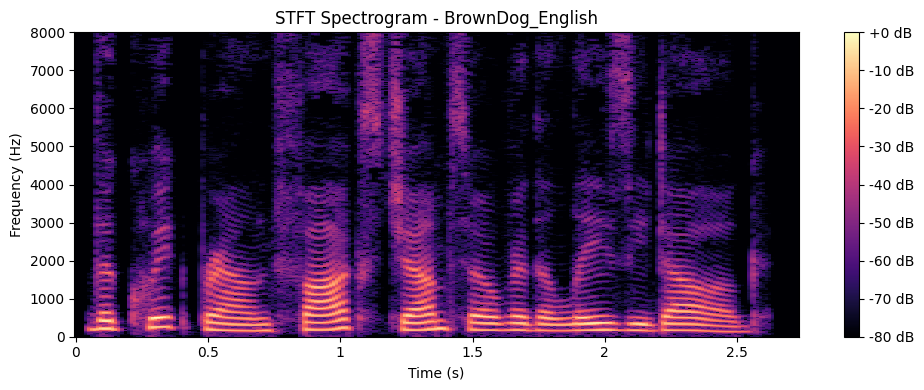

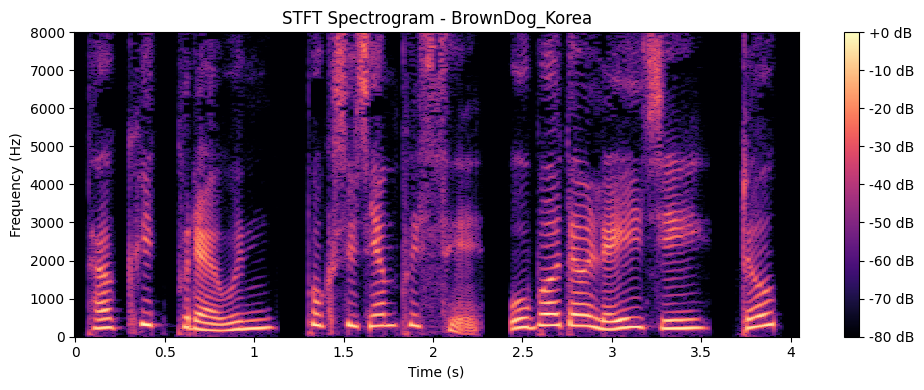

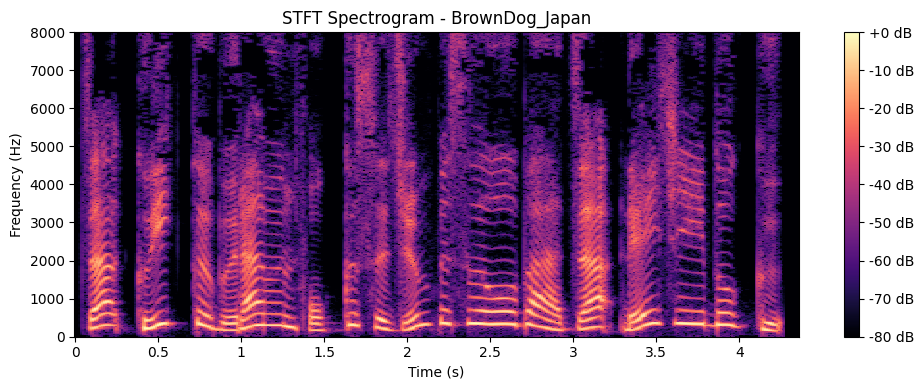

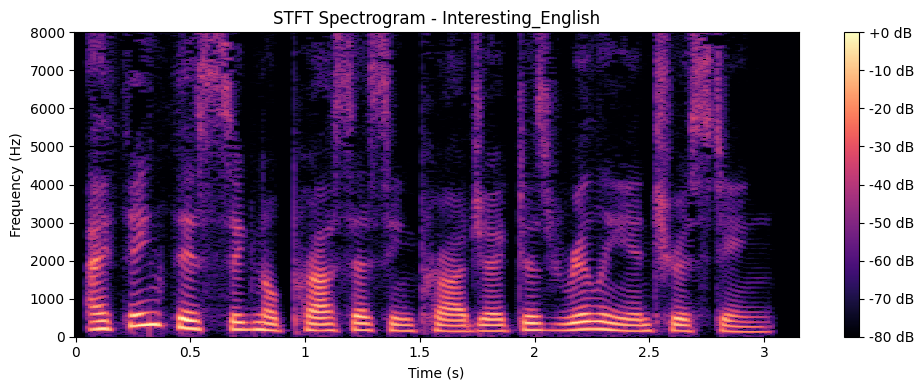

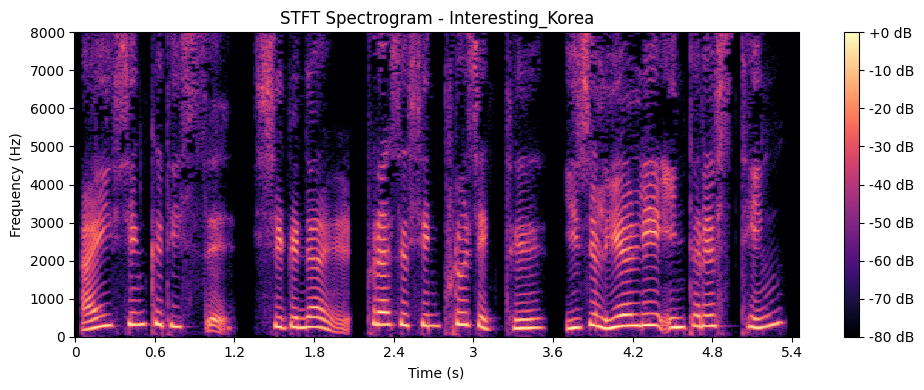

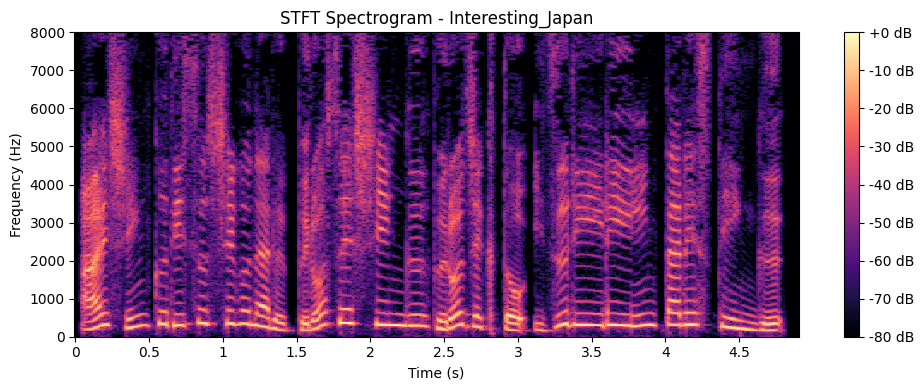

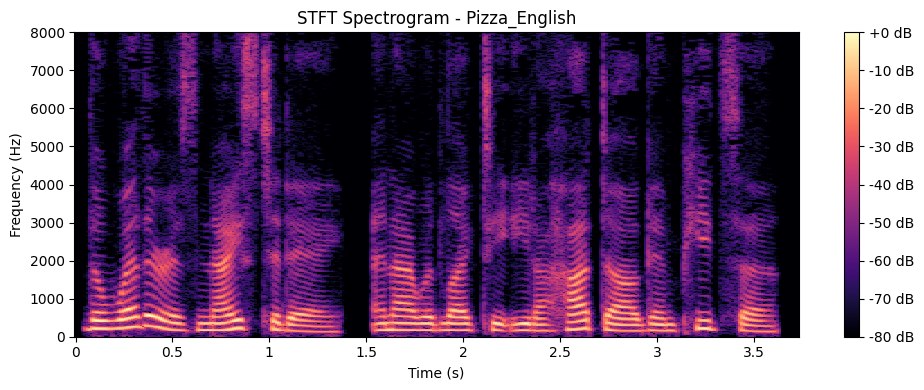

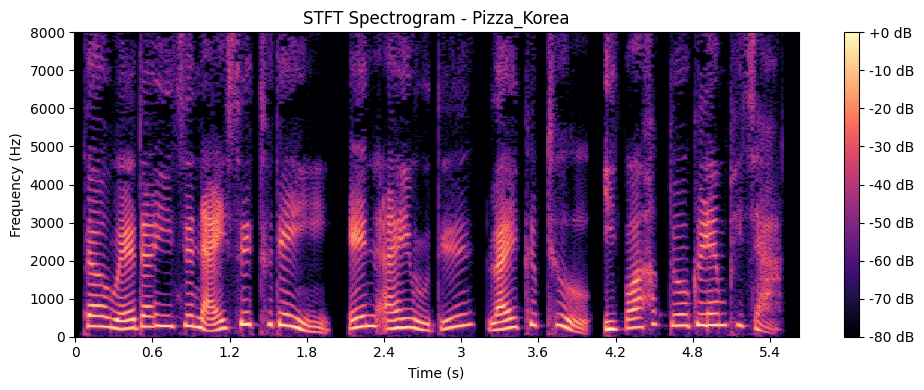

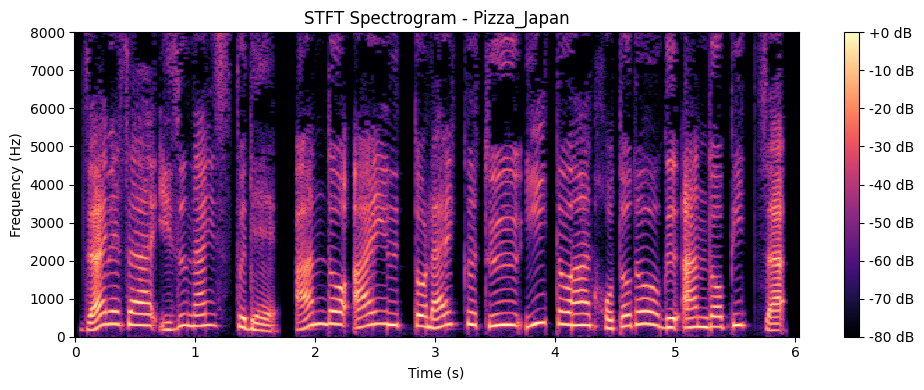

In [5]:
# Spectrogram 각각 보기
n_fft = 1024
hop_length = 256

for label, data in signals.items():
    y = data["y"]
    sr = data["sr"]

    D = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, window="hann")
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(
        S_db,
        sr=sr,
        hop_length=hop_length,
        x_axis="time",
        y_axis="hz"
    )
    plt.colorbar(format="%+2.0f dB")
    plt.title(f"STFT Spectrogram - {label}")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.ylim(0, 8000)
    plt.tight_layout()
    plt.show()
    plt.close()

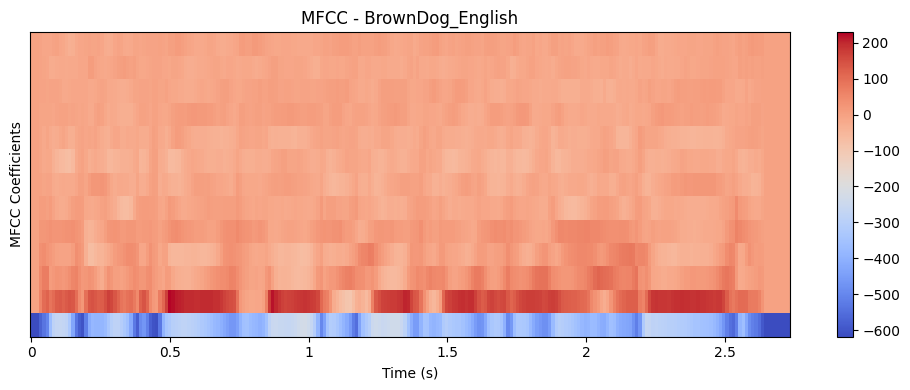

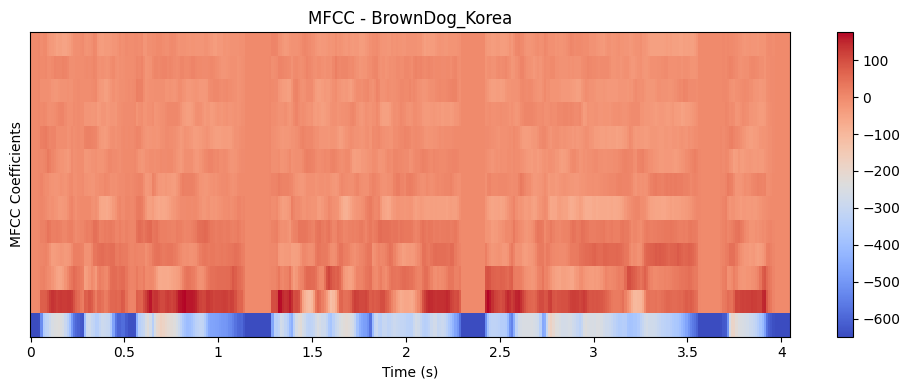

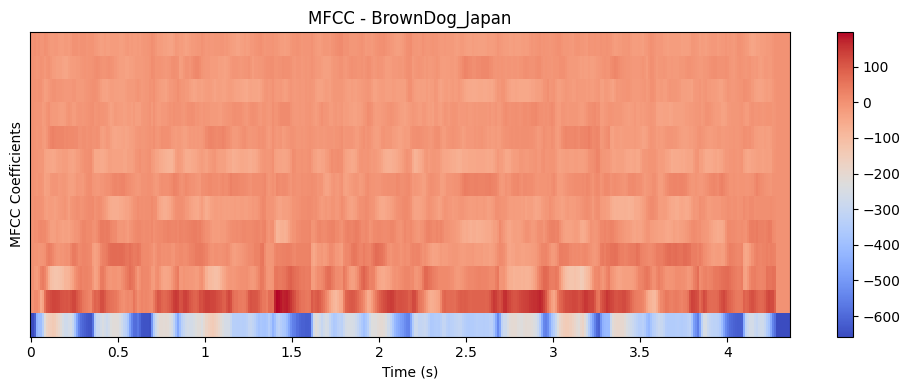

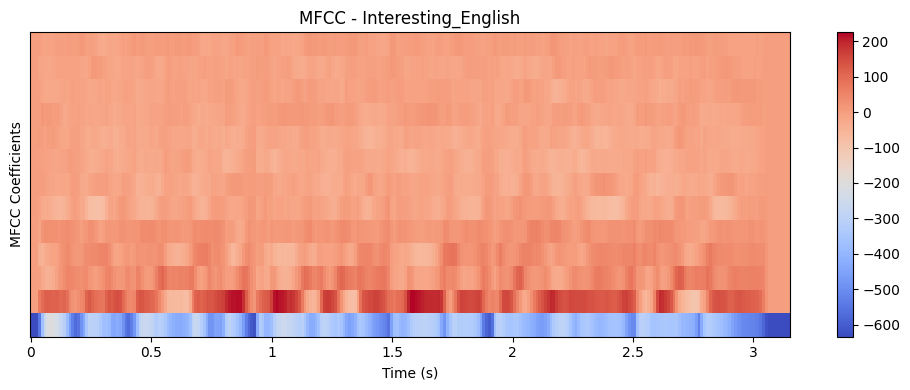

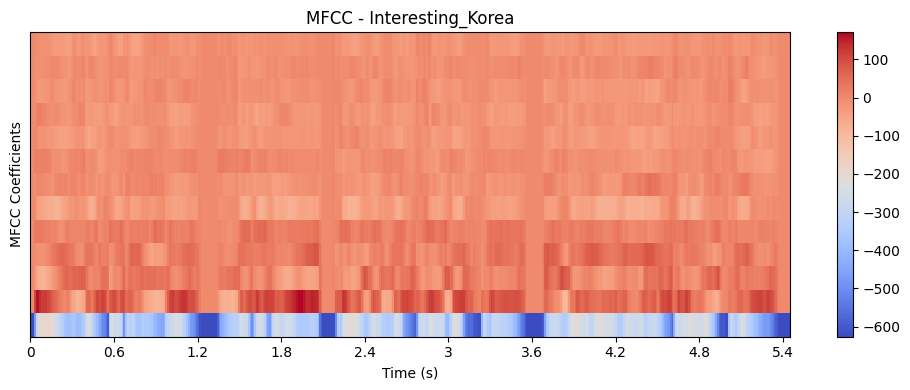

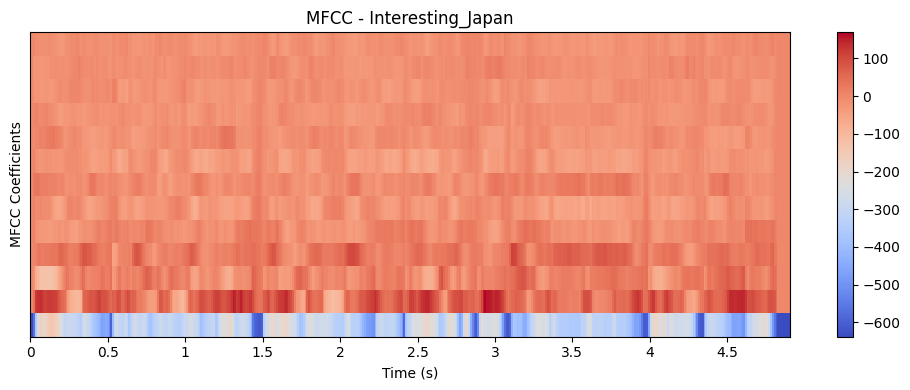

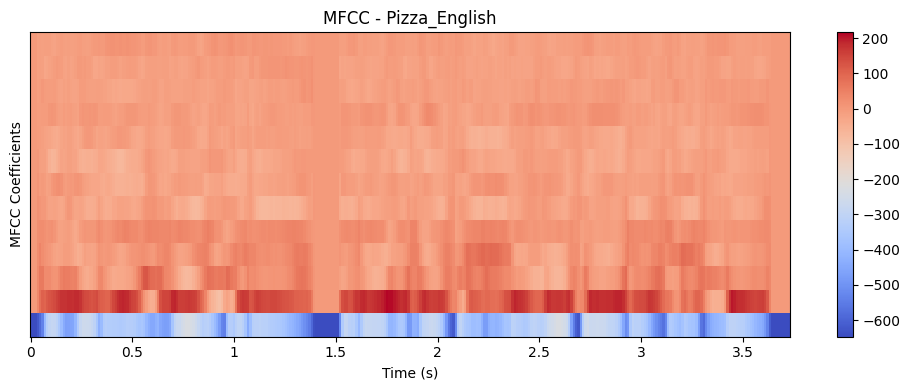

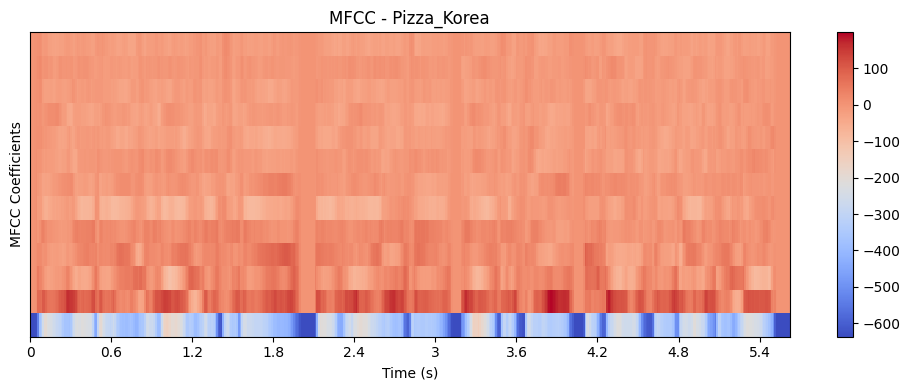

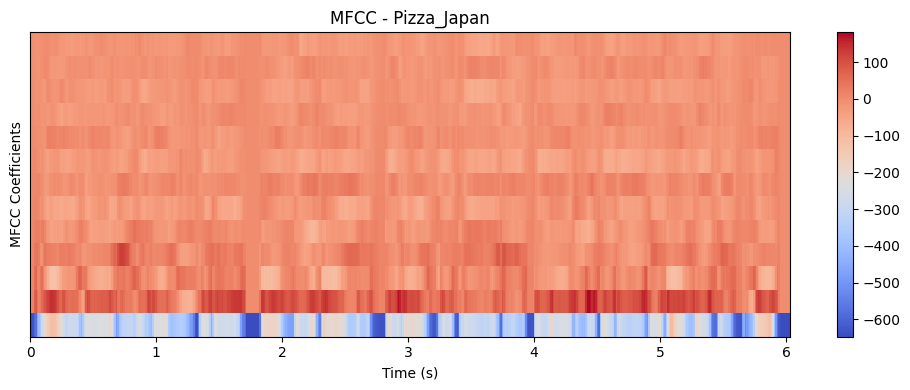

In [6]:
# + MFCC 각각 보기
mfcc_features = {}

for label, data in signals.items():
    y = data["y"]
    sr = data["sr"]

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13,
        n_fft=n_fft,
        hop_length=hop_length
    )

    mfcc_features[label] = mfcc

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(
        mfcc,
        sr=sr,
        hop_length=hop_length,
        x_axis="time"
    )
    plt.colorbar()
    plt.title(f"MFCC - {label}")
    plt.xlabel("Time (s)")
    plt.ylabel("MFCC Coefficients")
    plt.tight_layout()
    plt.show()
    plt.close()